In [2]:
%load_ext autoreload
%autoreload 2
!cd ~/dev1/scaling-laws-ecnn/

import pandas as pd
from typing import List, Tuple
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch
import rootutils
rootutils.setup_root(os.getcwd(), indicator=".git", pythonpath=True)

from src.data.mri.extract_slice import *

PATH = os.path.expanduser("~/Data/frischs/datasets/adni/")

In [42]:
tsv_location = os.path.join(PATH, "bids/participants.tsv")
df = pd.read_csv(tsv_location, sep="\t")
pd.set_option('display.max_columns', None)
df.head()

,alternative_id_1,participant_id,sex,education_level,age_bl,marital_status,ethnic_cat,adni_rid,site,original_study,diagnosis_sc,mmse_bl,adas11_bl,adas13_bl,apoe4,apoe_gen1,apoe_gen2,ravlt_immediate_bl,moca_bl,trabscor_bl,mpaccdigit_bl,mpacctrails_bl
0,011_S_0002,sub-ADNI011S0002,M,16,74.3,Married,Not Hisp/Latino,2,11,ADNI1,CN,28.0,10.67,18.67,0.0,3.0,3.0,44.0,NaN,112.0,-4.31028,-4.11443
1,011_S_0003,sub-ADNI011S0003,M,18,81.3,Married,Not Hisp/Latino,3,11,ADNI1,AD,20.0,22.00,31.00,1.0,3.0,4.0,22.0,NaN,148.0,-16.24490,-15.82990
2,022_S_0004,sub-ADNI022S0004,M,10,67.5,Married,Hisp/Latino,4,22,ADNI1,LMCI,27.0,14.33,21.33,0.0,3.0,3.0,37.0,NaN,271.0,-8.42150,-9.44935
3,011_S_0005,sub-ADNI011S0005,M,16,73.7,Married,Not Hisp/Latino,5,11,ADNI1,CN,29.0,8.67,14.67,0.0,3.0,3.0,37.0,NaN,90.0,-1.88868,-1.56583
4,100_S_0006,sub-ADNI100S0006,F,13,80.4,Married,Not Hisp/Latino,6,100,ADNI1,LMCI,25.0,18.67,25.67,0.0,3.0,3.0,30.0,NaN,168.0,-10.14170,-10.91090


In [43]:
df["diagnosis_sc"].value_counts()

LMCI    402
CN      229
AD      188
Name: diagnosis_sc, dtype: int64

data shape torch.Size([169, 208, 179])
torch.Size([208, 169])


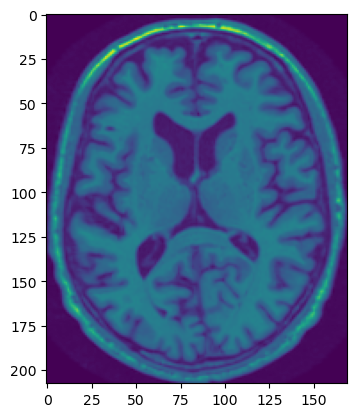

In [3]:
folder = "test2/linear_caps/subjects/sub-ADNI002S0295/ses-M006/t1_linear/sub-ADNI002S0295_ses-M006_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_T1w.nii.gz"
bids_image_path = os.path.join(PATH, folder)
data = nib.load(bids_image_path).get_fdata()
data = torch.tensor(data)
print("data shape", data.shape)
image = data[:,:,data.shape[2]//2]#.squeeze()
# flip image by 90 degrees to the right
image = image.rot90(1)
print(image.shape)
plt.imshow(image)
plt.show()

In [4]:
print(nib.load(bids_image_path).header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  3 169 208 179   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float64
bitpix          : 64
slice_start     : 0
pixdim          : [1. 1. 1. 1. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 0.0
qoffset_x       : -84.0
qoffset_y       : -119.0
qoffset_z       : -78.0
srow_x          : [  1.   0.   0. -84.]
srow_y  

max tensor(598.8652)
data shape torch.Size([1, 169, 208, 179])
max tensor(499.3261)
torch.Size([179, 208])


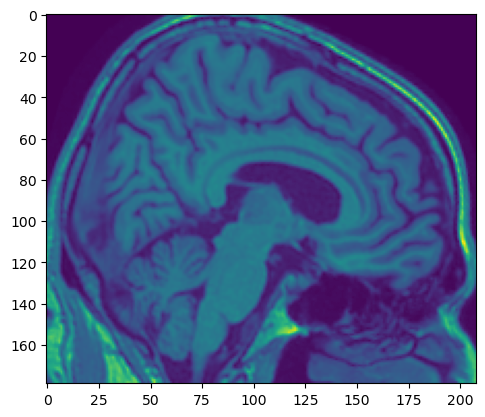

In [30]:
folder = "test2/linear_caps/subjects/sub-ADNI002S0295/ses-M000/deeplearning_prepare_data/image_based/t1_linear/sub-ADNI002S0295_ses-M000_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_T1w.pt"

folder = "test2/linear_caps/subjects/sub-ADNI002S0295/ses-M000/deeplearning_prepare_data/image_based/t1_linear/sub-ADNI002S0295_ses-M000_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_T1w.pt"
data : torch.Tensor = torch.load(os.path.join(PATH, folder))
print("max", data.max())
print("data shape", data.shape)
image = data[:,90,:,:].squeeze()
print("max", image.max())
# flip image by 90 degrees to the right
image = image.rot90(1)
print(image.shape)
plt.imshow(image)
plt.show()

In [24]:
bids_folder = "test2/bids/sub-ADNI002S0295/ses-M000/anat"
bids_image = "sub-ADNI002S0295_ses-M000_T1w.nii.gz"
bids_image_path = os.path.join(PATH, bids_folder, bids_image)

original_mri = nib.load(bids_image_path).get_fdata()
axial_slice_num = 52
sagittal_slice_num = 58
coronal_slice_num = 92
# extract slices
original_slices = {
    "axial": extract_slice_from_data(original_mri, axial_slice_num, 'axial'),
    "sagittal": extract_slice_from_data(original_mri, sagittal_slice_num, 'sagittal'),
    "coronal": extract_slice_from_data(original_mri, coronal_slice_num, 'coronal'),
}

postprocessed_slices 1146.7808837890625


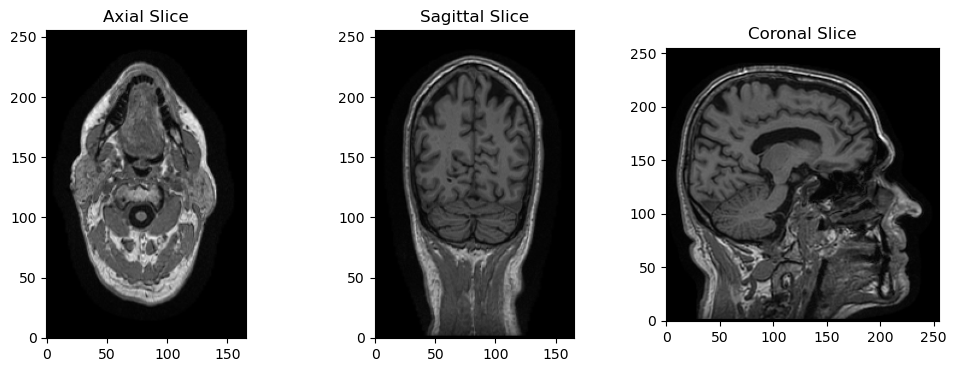

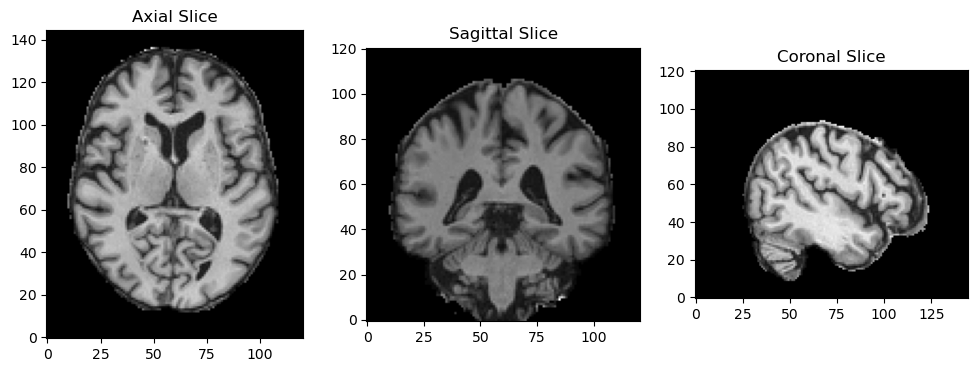

In [27]:
caps_folder = "test2/caps/subjects/sub-ADNI002S0295/ses-M000/t1/spm/segmentation/normalized_space/"
caps_folder = os.path.join(PATH, caps_folder)
postprocessed_slices = extract_slices(caps_folder, use_seg_mask=True)
print("postprocessed_slices", np.max(postprocessed_slices["axial-52"]))

plot_slices(original_slices)
plot_slices(postprocessed_slices)

(166, 256) /home/frischs/Data/frischs/datasets/adni/test2/bids/sub-ADNI002S0295/ses-M000/anat/sub-ADNI002S0295_ses-M000_T1w.nii.gz
(121, 145) /home/frischs/Data/frischs/datasets/adni/test2/caps/subjects/sub-ADNI002S0295/ses-M000/t1/spm/segmentation/normalized_space/sub-ADNI002S0295_ses-M000_T1w_segm-whitematter_space-Ixi549Space_modulated-off_probability.nii.gz


(3, 256, 166) /home/frischs/Data/frischs/datasets/adni/test2/caps/subjects/sub-ADNI002S0295/ses-M000/t1/spm/segmentation/normalized_space/sub-ADNI002S0295_ses-M000_T1w_target-Ixi549Space_transformation-inverse_deformation.nii.gz
Error extracting slices for /home/frischs/Data/frischs/datasets/adni/test2/caps/subjects/sub-ADNI002S0295/ses-M000/t1/spm/segmentation/normalized_space/sub-ADNI002S0295_ses-M000_T1w_target-Ixi549Space_transformation-inverse_deformation.nii.gz
(121, 145) /home/frischs/Data/frischs/datasets/adni/test2/caps/subjects/sub-ADNI002S0295/ses-M000/t1/spm/segmentation/normalized_space/sub-ADNI002S0295_ses-M000_T1w_segm-graymatter_space-Ixi549Space_modulated-off_probability.nii.gz
(3, 145, 121) /home/frischs/Data/frischs/datasets/adni/test2/caps/subjects/sub-ADNI002S0295/ses-M000/t1/spm/segmentation/normalized_space/sub-ADNI002S0295_ses-M000_T1w_target-Ixi549Space_transformation-forward_deformation.nii.gz
Error extracting slices for /home/frischs/Data/frischs/datasets/adn

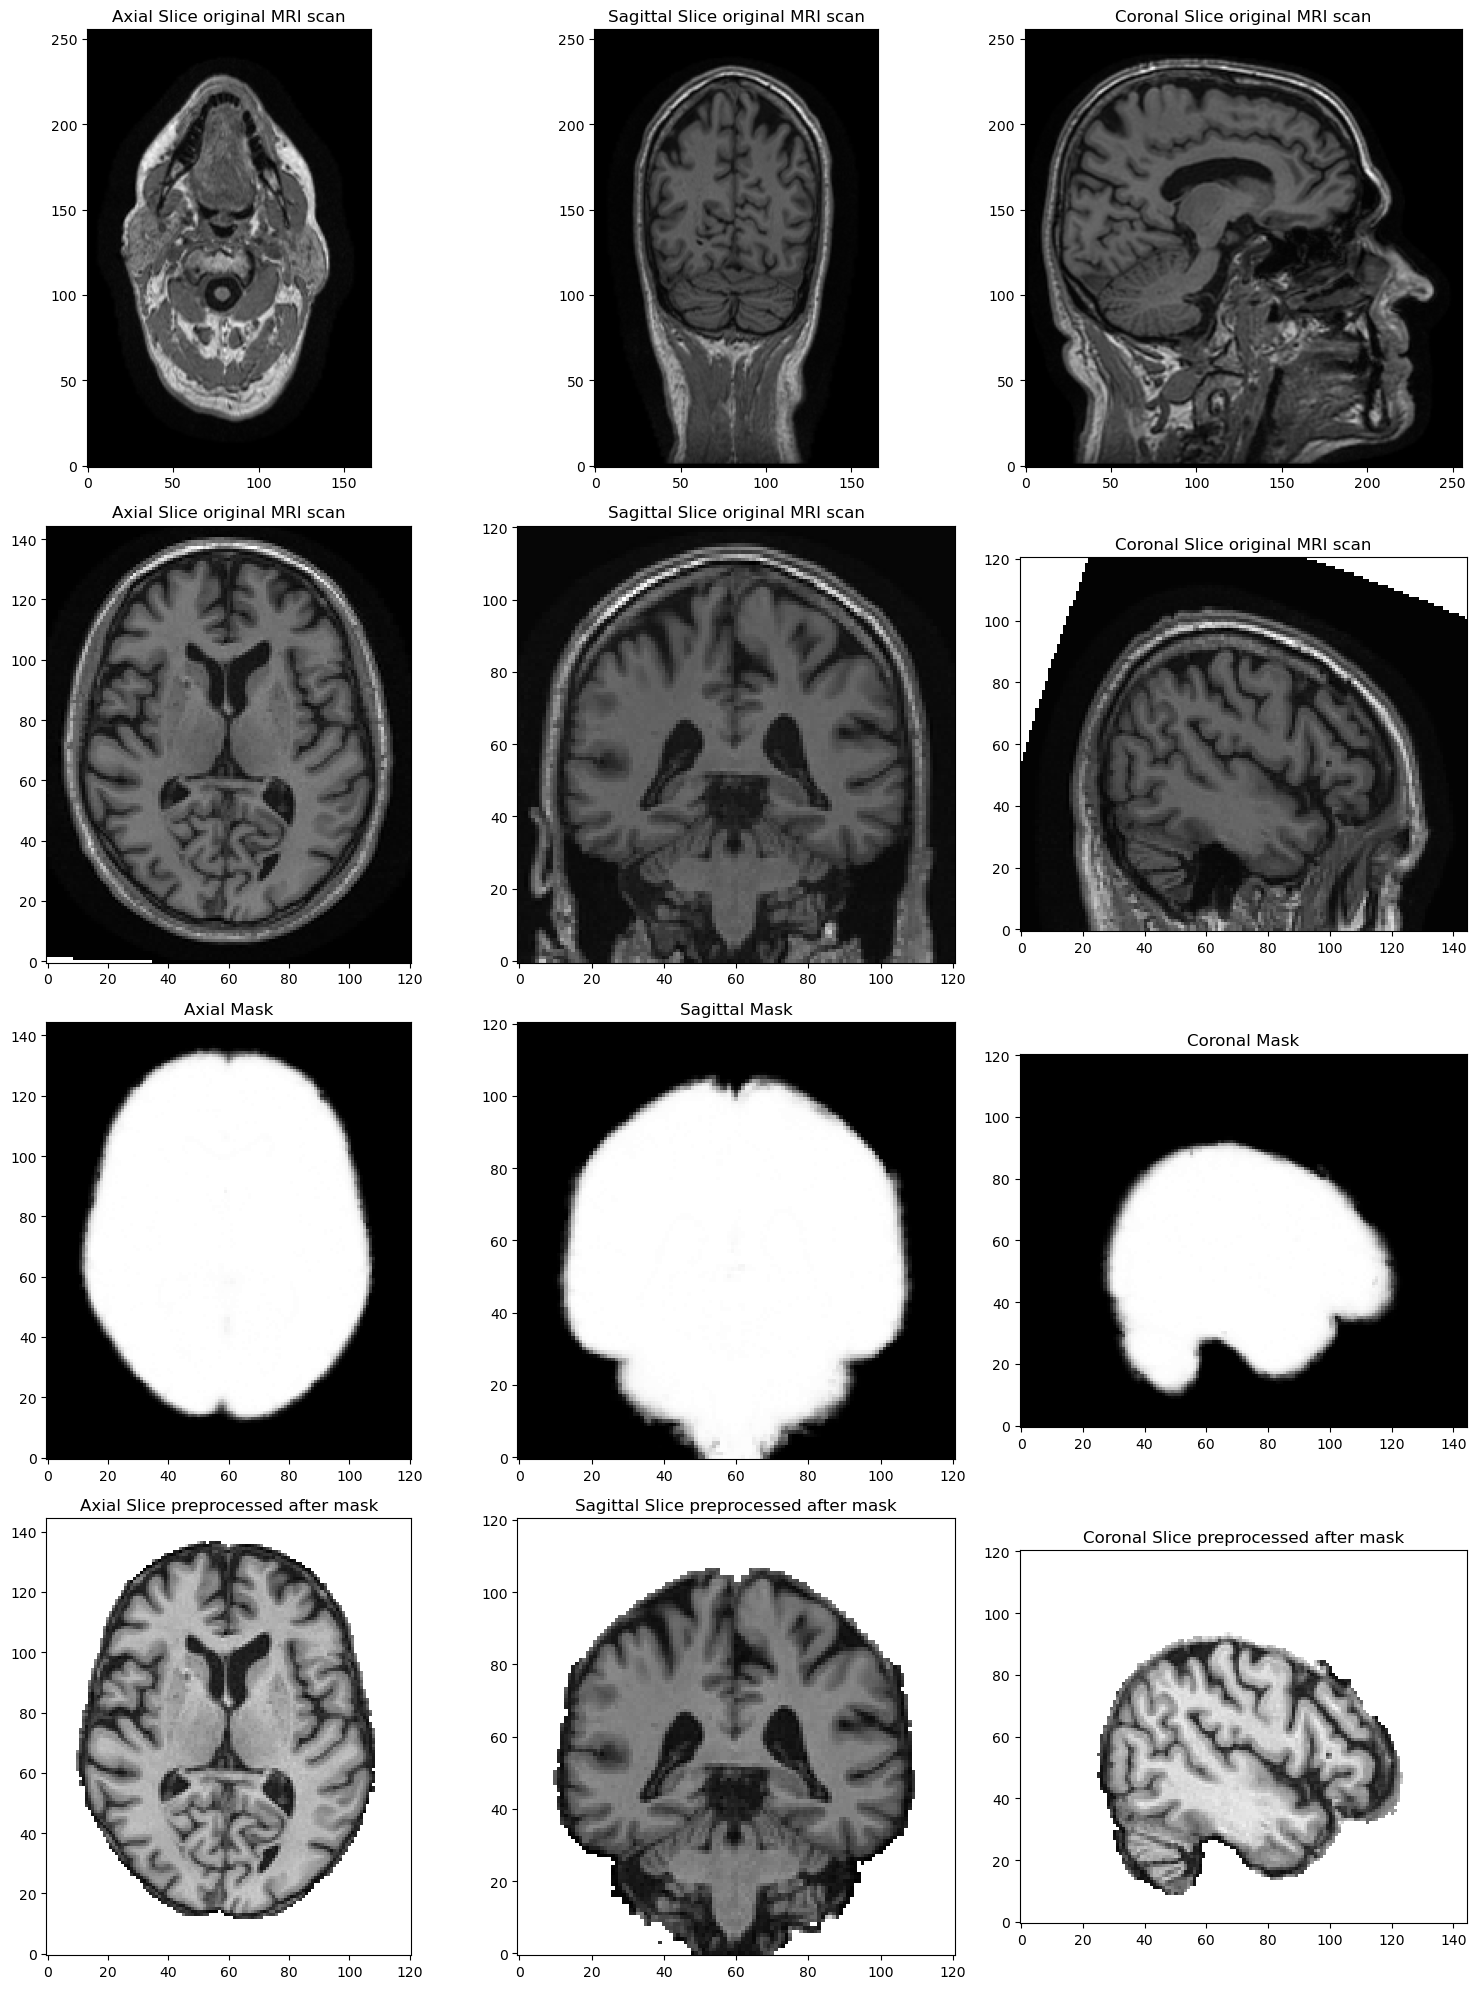

In [9]:
def plot_slices(file_paths: List[str]):
    axial_slice_num = 52
    sagittal_slice_num = 58
    coronal_slice_num = 92

    axial_seg = []
    sagittal_seg = []
    coronal_seg = []

    fig, axes = plt.subplots(4, 3, figsize=(15, 5*4))
    axes = axes.flatten()
    i=0
    for file_path in file_paths:
        # Extract slices
        axial_slice = extract_slice(file_path, axial_slice_num, 'axial')
        sagittal_slice = extract_slice(file_path, sagittal_slice_num, 'sagittal')
        coronal_slice = extract_slice(file_path, coronal_slice_num, 'coronal')

        print(axial_slice.shape, file_path)

        if len(axial_slice.shape) == 3:
            print(f"Error extracting slices for {file_path}")
            continue

        if "segm" in file_path.split("/")[-1]:
            # we save them and lay them over each other
            axial_seg.append(axial_slice)
            sagittal_seg.append(sagittal_slice)
            coronal_seg.append(coronal_slice)
            continue

        # Display slices for verification
        if i == 0:
            title = "original MRI scan"
        if i == 1:
            title = "preprocessed MRI scan"

        axes[i].imshow(axial_slice.T, cmap='gray', origin='lower')
        axes[i].set_title(f'Axial Slice {title}')
        axes[i+1].imshow(sagittal_slice.T, cmap='gray', origin='lower')
        axes[i+1].set_title(f'Sagittal Slice {title}')
        axes[i+2].imshow(coronal_slice.T, cmap='gray', origin='lower')
        axes[i+2].set_title(f'Coronal Slice {title}')

        i+=3
    
    # Display the segmentation
    axial_mask = np.stack(axial_seg, axis=0).sum(axis=0)
    sagittal_mask = np.stack(sagittal_seg, axis=0).sum(axis=0)
    coronal_mask = np.stack(coronal_seg, axis=0).sum(axis=0)
    axes[i].imshow(axial_mask.T, cmap='gray', origin='lower')
    axes[i].set_title('Axial Mask')
    axes[i+1].imshow(sagittal_mask.T, cmap='gray', origin='lower')
    axes[i+1].set_title('Sagittal Mask')
    axes[i+2].imshow(coronal_mask.T, cmap='gray', origin='lower')
    axes[i+2].set_title('Coronal Mask')

    i += 3

    # use mask
    axial_slice = np.ma.masked_where(axial_mask == 0, axial_slice)
    sagittal_slice = np.ma.masked_where(sagittal_mask == 0, sagittal_slice)
    coronal_slice = np.ma.masked_where(coronal_mask == 0, coronal_slice)

    # Display slices for verification
    axes[i].imshow(axial_slice.T, cmap='gray', origin='lower')
    axes[i].set_title('Axial Slice preprocessed after mask')
    axes[i+1].imshow(sagittal_slice.T, cmap='gray', origin='lower')
    axes[i+1].set_title('Sagittal Slice preprocessed after mask')
    axes[i+2].imshow(coronal_slice.T, cmap='gray', origin='lower')
    axes[i+2].set_title('Coronal Slice preprocessed after mask')

    plt.tight_layout()
    plt.show()
    

# Specify file path and slices to extract
bids_folder = "test2/bids/sub-ADNI002S0295/ses-M000/anat"
bids_image = "sub-ADNI002S0295_ses-M000_T1w.nii.gz"
bids_image_path = os.path.join(PATH, bids_folder, bids_image)

paths = [bids_image_path]

caps_folder = "test2/caps/subjects/sub-ADNI002S0295/ses-M000/t1/spm/segmentation/normalized_space/"
#caps_folder = "test2/caps/subjects/sub-ADNI002S0295/ses-M000/t1/spm/segmentation/dartel_input/"
caps_image = 'sub-ADNI002S0295_ses-M000_T1w_segm-csf_space-Ixi549Space_modulated-off_probability.nii.gz'
caps_image_path = os.path.join(PATH, caps_folder, caps_image)

for image in os.listdir(os.path.join(PATH, caps_folder)):
    paths.append(os.path.join(PATH, caps_folder, image))
    

plot_slices(paths)


In [51]:
def join_unique_columns(df1, col1, df2, col2):
    # Check if the values in the columns are unique within each DataFrame
    if df1[col1].is_unique and df2[col2].is_unique:
        # Check if there's any intersection between the values in the two columns
        if not set(df1[col1]).intersection(set(df2[col2])):
            # Perform the join
            result = pd.merge(df1, df2, how='inner', left_on=col1, right_on=col2)
            return result
        else:
            print("Cannot perform join: Intersection of values in the columns is not empty.")
            return None
    else:
        print("Cannot perform join: Values in one or both columns are not unique.")
        print("df1: ", df1[col1].value_counts().head())
        print("df2: ", df2[col2].value_counts().head())
        return None

result = join_unique_columns(image_df, "ID", df, "ID")

Cannot perform join: Values in one or both columns are not unique.
df1:  126_S_0605_2008-06-30    4
023_S_0604_2009-07-10    3
052_S_1346_2007-03-13    3
023_S_1247_2008-08-12    3
128_S_1148_2008-01-17    3
Name: ID, dtype: int64
df2:  128_S_1088_2013-01-23    2
941_S_1195_2011-02-15    2
035_S_4783_2014-03-13    2
114_S_0166_2012-02-13    1
098_S_0171_2011-04-05    1
Name: ID, dtype: int64


In [20]:
value_counts = df.groupby(['COLPROT', 'DX_bl', 'FLDSTRENG']).size().reset_index(name='counts')
value_counts

,COLPROT,DX_bl,FLDSTRENG,counts
0,ADNI1,AD,1.5 Tesla MRI,613
1,ADNI1,CN,1.5 Tesla MRI,1031
2,ADNI1,CN,3 Tesla MRI,2
3,ADNI1,LMCI,1.5 Tesla MRI,1883
4,ADNI1,LMCI,3 Tesla MRI,2
5,ADNI2,AD,3 Tesla MRI,423
6,ADNI2,CN,1.5 Tesla MRI,116
7,ADNI2,CN,3 Tesla MRI,894
8,ADNI2,EMCI,3 Tesla MRI,1089
9,ADNI2,LMCI,1.5 Tesla MRI,123
